In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
df = pd.read_csv('netflix_titles.csv')

In [4]:
import pandas as pd
import numpy as np

Shape of dataset

In [5]:
df.shape

(8807, 12)

In [6]:
print(f"[LOAD]  Missing values:\n{df.isnull().sum()}\n")

[LOAD]  Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64



In [7]:
print(f"[LOAD]  Duplicates: {df.duplicated().sum()}")

[LOAD]  Duplicates: 0


Missing values

In [8]:
df['director'] = df['director'].fillna('Unknown')

In [9]:
df['cast']     = df['cast'].fillna('Unknown')

In [10]:
df['country']  = df['country'].fillna('Unknown')

In [11]:
before = len(df)
df.dropna(subset=['rating', 'duration'], inplace=True)
print(f"[CLEAN] Dropped {before - len(df)} rows with missing rating/duration.")

[CLEAN] Dropped 7 rows with missing rating/duration.


In [13]:
print(f"[LOAD]  Missing values:\n{df.isnull().sum()}\n")

[LOAD]  Missing values:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64



Standardize formats

In [15]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

missing_dates = df['date_added'].isnull().sum()
print(f"[FORMAT] date_added parsed. Still unparseable: {missing_dates}")

[FORMAT] date_added parsed. Still unparseable: 10


In [16]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
print(f"[LOAD]  Missing values:\n{df.isnull().sum()}\n")

[LOAD]  Missing values:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64



In [18]:
df = df.dropna(subset=['date_added'])

In [19]:
df['date_added'].isnull().sum()

np.int64(0)

In [20]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [21]:
df.shape

(8790, 12)

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


Movies vs TV shows on Netflix

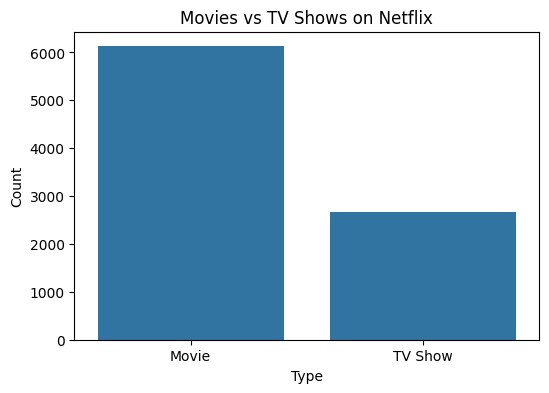

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

Netflix Content Growth Over Years

/tmp/ipykernel_671/868942742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_added'] = df['date_added'].dt.year


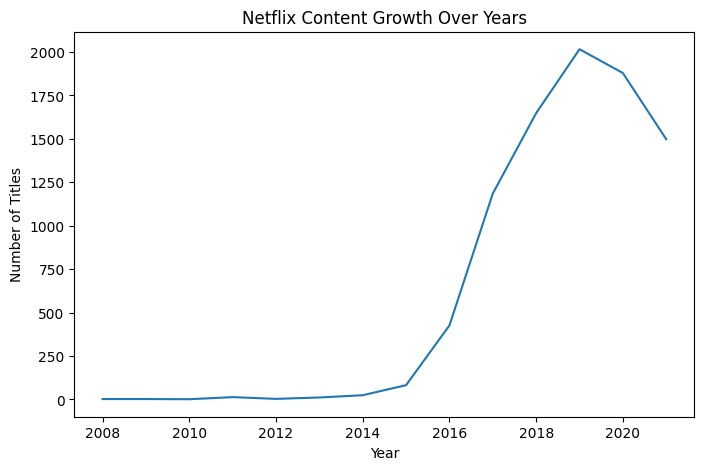

In [25]:
df['year_added'] = df['date_added'].dt.year

growth = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(8,5))
growth.plot(kind='line')

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

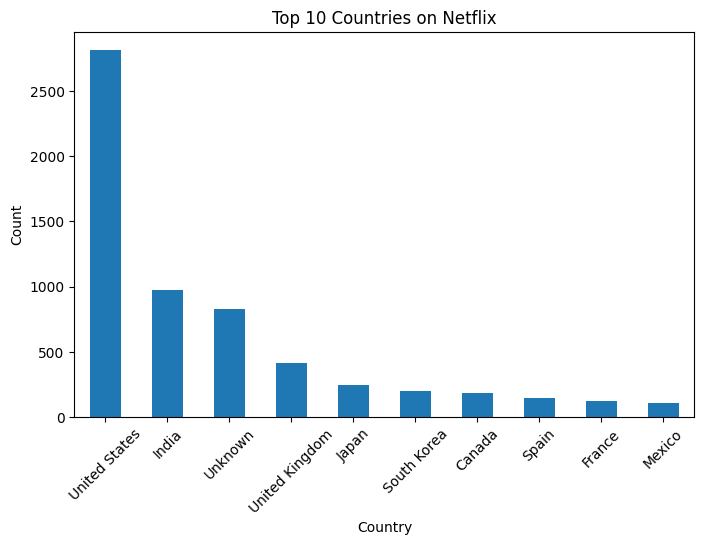

In [26]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')

plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

Top Genres on Netflix

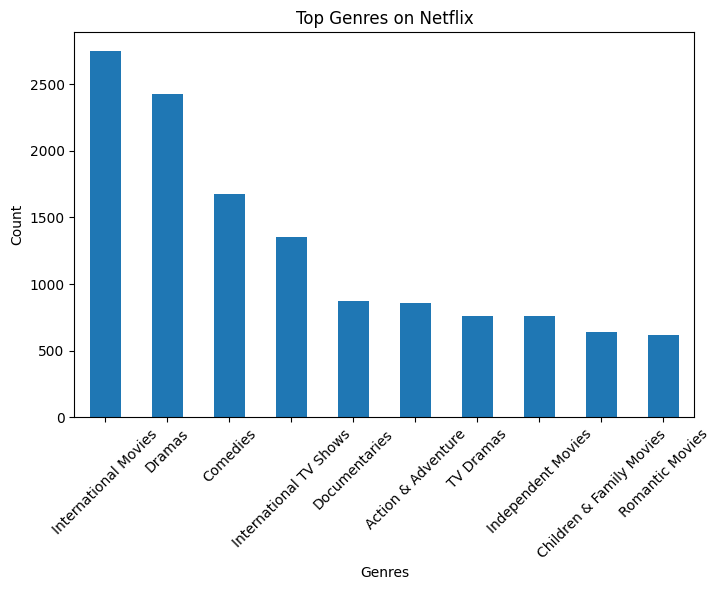

In [27]:

genres = df['listed_in'].str.split(', ').explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(8,5))
top_genres.plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [29]:
df.to_csv("cleaned_netflix_data.csv", index=False)

In [30]:
files.download('cleaned_netflix_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')